# **Importing Libraries**

In [1]:
# Standard Library Imports
import os            # OS-level operations (paths, directory handling)
import math          # Mathematical functions
import shutil        # High-level file operations (copying, moving, deleting)

# Data Handling & Processing
import numpy as np               # Numerical computations and array operations
import pandas as pd              # Data manipulation and analysis
import h5py                      # Handling HDF5 file formats

# Progress Visualization
from tqdm import tqdm            # Progress bars for loops

# Plotting & Visualization
import matplotlib.pyplot as plt  # Plotting and visualization tools


# PyTorch Machine Learning Stack
import torch                     # Core PyTorch library
import torch.nn as nn            # Neural network layers and utilities
import torch.optim as optim      # Optimization algorithms (SGD, Adam, etc.)
from torch.utils.data import (   # Dataset and DataLoader utilities
    DataLoader,
    Dataset
)
# Metrics
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from scipy.stats import rankdata

# **Defining the architecture of sparse autoencoder**

In [2]:
"""
Sparse Autoencoder model.

Anthropic-style ReLU SAE with L1 sparsity penalty and unit-norm decoder
columns, following Bricken et al. (2023).
"""
import torch
import torch.nn as nn


class SparseAutoencoder(nn.Module):
    """ReLU sparse autoencoder for decomposing neural network activations.

    Args:
        d_input: Dimensionality of the input activations.
        d_hidden: Dictionary size (number of latent features).
    """

    def __init__(self, d_input: int, d_hidden: int):
        super().__init__()
        self.d_input = d_input
        self.d_hidden = d_hidden
        self.W_enc = nn.Linear(d_input, d_hidden, bias=True)
        self.W_dec = nn.Linear(d_hidden, d_input, bias=True)
        with torch.no_grad():
            self.W_dec.weight.data = nn.functional.normalize(
                self.W_dec.weight.data, dim=0
            )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Encode input activations into sparse feature activations."""
        return torch.relu(self.W_enc(x - self.W_dec.bias))

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode sparse features back to activation space."""
        return self.W_dec(z)

    def forward(self, x: torch.Tensor):
        """Full forward pass: encode then decode.

        Returns:
            x_hat: Reconstructed activations.
            z: Sparse feature activations.
        """
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

    def loss(self, x: torch.Tensor, lam: float):
        """Compute SAE loss = MSE + lambda * L1.

        Returns:
            total_loss, mse, l1, z
        """
        x_hat, z = self.forward(x)
        mse = (x - x_hat).pow(2).mean()
        l1 = z.abs().mean()
        return mse + lam * l1, mse, l1, z

    def normalize_decoder(self):
        """Constrain decoder column norms to unity (call after each step)."""
        with torch.no_grad():
            self.W_dec.weight.data = nn.functional.normalize(
                self.W_dec.weight.data, dim=0
            )

# **Defining custom dataset class for training on activations**

In [3]:
# Dataset class
class ActivationDataset(Dataset):
    def __init__(self, activation_path):
        self.x = torch.load(activation_path).float()
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx]

# **Function to get Sparse Features**

In [4]:
def get_sparse_features(activation_path, weight_path, latent_dim, device="cuda"):
    """
    A Function to get sparse features from sparse autoencoders

    parameters
    ----------
    activation_path: Path to activations dataset
    weight_path: Path to weights of trained SAE
    Latent dim: Dictionary size of the SAE

    Returns: Numpy array of sparse features
    """

    # Load the activation dataset
    x = torch.load(
        activation_path
    )

    # get the embedding dim
    input_dim = x.shape[1]
    # Load the trained sparse autoencoder
    model = SparseAutoencoder(
        input_dim,
        latent_dim
    )
    model.load_state_dict(
        torch.load(
            weight_path,
            map_location=device
        )["model"]
    )
    # Move the model to device
    model.to(device)
    # Set the model to eval mode
    model.eval()
    with torch.no_grad():
        x_device = x.to(device)

        # Get the sparse features for activation dataset
        z = model.encode(
            x_device
        )
        print("Shape of the sparse autoencoder output")
        print(z.shape)

        # find out the number of total alive features
        active = z > 0
        alive_features = active.any(dim=0)
        num_alive = alive_features.sum().item()
        # print the alive features
        print("Alive features")
        print(num_alive)
        # Print the total dictionary size
        num_total = z.shape[1]
        print("Total dictionary size")
        print(num_total)

        # reconstruction error (mean + variance across samples)
        x_hat = model.decode(z)
        per_sample_err = ((x_hat - x_device) ** 2).mean(dim=1)  # (n_samples,)
        recon_error_mean = per_sample_err.mean().item()
        recon_error_var = per_sample_err.var().item()

        print("Reconstruction error (mean)")
        print(recon_error_mean)
        print("Reconstruction error (variance)")
        print(recon_error_var)

    return z.cpu(), recon_error_mean, recon_error_var

# **Function to load the labels and Subject ids**

In [5]:
def load_analysis_data(label_path, subject_path):
    # loading the labels
    labels=torch.load(label_path).numpy()
    # loading the subject ids
    subjects=torch.load(subject_path).numpy()
    return labels,subjects

# **Function to do the task specific analysis**

In [6]:
def attention_specificity(features, labels, layer, activation_seed, top_k=20, save_path=None):
    """
    Analyze attention specificity of SAE features.
    Parameters
    ----------
    features : np.ndarray
        Sparse feature matrix
        Shape = (N_samples, N_features)

    labels : np.ndarray
        Binary labels
        0 = attended to left speaker
        1 = Attended to right speaker
    top_k : int
        Number of highest AUROC features to display.
    layer: string
        layer from which the activation is extracted
    save_path : str or None
        Folder to save figures. If None, figures are only shown.

    Returns
    -------
    results : dict
        scores
        raw_auc
        directions
        best_feature
        best_score
        top_features
    """

    print("ATTENTION SPECIFIC FEATURE ANALYSIS")

    # List to accumulate auc scores, raw auc scores and attended direction
    scores = []
    raw_scores = []
    directions = []
    # Initializing best feature and best score
    best_feature = None
    best_score = -1
    # Compute AUROC of every feature
    # loop over each feature
    for j in range(features.shape[1]):
        # get the feature j over all samples
        feature = features[:, j]
        # if standard deviation of feature j over all all rows is less than 1e-8,
        # then that feature is mostly zero
        if feature.std() < 1e-8:
            # so we discard that feature and give score of 0 to that feature
            scores.append(0.0)
            raw_scores.append(0.5)
            directions.append("Dead")
            # we skip remaining of the steps
            continue

        # get the auroc score for the feature
        raw_auc = roc_auc_score(labels, feature)
        # if the auc is greater than 0.5 then the feature is specific for right direction attention
        if raw_auc >= 0.5:
            direction = "Attended to right speaker"
            score = raw_auc
        # otherwise
        else:
            # the feature attends to left direction
            direction = "Attended to left speaker"
            score = 1 - raw_auc

        # Accumulate the scores and attended directions
        scores.append(score)
        raw_scores.append(raw_auc)
        directions.append(direction)
        # save the best score so far
        if score > best_score:
            best_score = score
            best_feature = j

    # get numpy array for scores and raw scores
    scores = np.array(scores)
    raw_scores = np.array(raw_scores)
    # Print summary
    print(f"\nBest Feature : {best_feature}")
    print(f"Best AUROC   : {best_score:.4f}")
    print(f"Detects      : {directions[best_feature]}")
    # Top features
    idx = np.argsort(scores)[::-1][:top_k]
    print(f"TOP {top_k} ATTENTION FEATURES")
    print(
        f"{'Rank':<6}"
        f"{'Feature':<10}"
        f"{'AUROC':<10}"
        f"{'Detects'}"
    )
    for rank, i in enumerate(idx, 1):
        print(
            f"{rank:<6}"
            f"{i:<10}"
            f"{scores[i]:<10.3f}"
            f"{directions[i]}"
        )

    
    # Scatter Plot
    plt.figure(figsize=(3.5, 2.6))
    # sort the scores
    sorted_idx = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_idx]
    # Defining the colors for each direction
    sorted_colors = []
    for i in sorted_idx:
        if directions[i] == "Attended to right speaker":
            sorted_colors.append("tab:blue")
        elif directions[i] == "Attended to left speaker":
            sorted_colors.append("tab:red")
        else:
            sorted_colors.append("gray")
    # line Plot
    plt.plot(sorted_scores, linewidth=2)
    # scatter plot
    plt.scatter(np.arange(len(sorted_scores)), sorted_scores, c=sorted_colors, s=18)
    plt.xlabel("Features (Ranked)")
    plt.ylabel("Best AUROC")
    plt.title(f"Ranked Attention Selectivity of SAE Features ({layer} layer)")
    plt.grid(alpha=0.3)
    # Saving the plot
    if save_path is not None:
        plt.savefig(
            f"{save_path}/attention_all_features_{layer}_{activation_seed}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()
    # Bargraph
    plt.figure(figsize=(3.5, 2.6))
    # define the colors
    bar_colors = []
    for i in idx:
        if directions[i] == "Attended to right speaker":
            bar_colors.append("tab:blue")
        elif directions[i] == "Attended to left speaker":
            bar_colors.append("tab:red")
        else:
            bar_colors.append("gray")
    # plotting the bar graph
    plt.bar(
        np.arange(top_k),
        scores[idx],
        color=bar_colors
    )
    plt.xticks(
        np.arange(top_k),
        idx,
        rotation=90
    )
    plt.ylabel("AUROC")
    plt.xlabel("Feature Index")
    plt.title(f"Top {top_k} Attention Features ({layer} layer)")
    # save the bar graph
    if save_path is not None:
        plt.savefig(
            f"{save_path}/attention_top_features_{layer}_{activation_seed}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()
    # Return everything
    return {
        "scores": scores,
        "raw_auc": raw_scores,
        "directions": directions,
        "best_feature": best_feature,
        "best_score": best_score,
        "top_features": idx
    }

# **Function to analyze the subject specificity**

In [7]:
def subject_specificity(features, subjects, layer, activation_seed, save_path = None):
    """
    Analyze subject specificity of SAE features.
    Parameters
    ----------
    features : np.ndarray
        Sparse feature matrix
        Shape = (N_samples, N_features)

    Subjects : np.ndarray
        Subject ids associated with each sample
    layer: string
        layer from which the activation is extracted
    save_path : str or None
        Folder to save figures. If None, figures are only shown.

    Returns
    -------
    results : numpy array
        Array stores the best auc for each subject
    """

    print("SUBJECT SPECIFIC FEATURE ANALYSIS")
    # Get the unique subjects
    unique=np.unique(subjects)
    # List to accumulate the results
    results=[]
    # loop over each unique subject id
    for sid in unique:
        # Develop a binary, which has 1 for the sample which has subject id sid
        y=(subjects==sid).astype(int)
        # initialize the best score for this subject id
        best=0
        # initialize the best feature for this subject id
        feat=0
        # For each feature
        for j in range(features.shape[1]):
            # if a feature is dead, then discard it and continue
            if features[:,j].std()<1e-8:
                continue
            # Get auroc score
            auc=roc_auc_score(y, features[:,j])
            auc=max(auc, 1-auc)
            # Get the best auroc and feature
            if auc>best:
                best=auc
                feat=j
        # display result
        print(f"Subject {sid:2d} | " f"Best Feature {feat:3d} | "f"AUROC {best:.3f}")
        # Accumulated the results
        results.append(best)

    # Plotting the bar graph
    plt.figure(figsize=(3.5, 2.6))
    plt.bar(unique,results)
    plt.xlabel("Subject")
    plt.ylabel("Best AUROC")
    plt.title(f"Subject Specificity ({layer} layer)")
    # save the bar graph
    if save_path is not None:
        plt.savefig(
            f"{save_path}/subject_specificity_{layer}_{activation_seed}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()
    return np.array(results)

# **Function to compare task versus subject specificity**

In [8]:
def task_vs_subject_analysis(features, labels, subjects, layer, activation_seed, save_path=None):
    """
    Compare attention selectivity and subject selectivity
    for every SAE feature.
    Parameters
    ----------
    features : ndarray
        (N, D)
    labels : ndarray
        Binary attention labels.
    subjects : ndarray
        Subject IDs.
    layer: string
        layer from which the activation is extracted
    save_path : str or None
        Folder to save figures. If None, figures are only shown.
    Returns
    -------
    results : dict
    """
    print("TASK vs SUBJECT FEATURE ANALYSIS")
    # get the unique subjects
    unique_subjects = np.unique(subjects)
    # Lists to accumulate task and subject score
    task_scores = []
    subject_scores = []
    # loop over each feature
    for j in range(features.shape[1]):
        # get the feature j
        feature = features[:, j]
        # if the feature is dead, then discard it
        if feature.std() < 1e-8:
            task_scores.append(0)
            subject_scores.append(0)
            continue
        # Get the attention auroc
        auc = roc_auc_score(labels, feature)
        task_auc = max(auc, 1 - auc)
        # initialize the best subject auroc
        best_subject_auc = 0
        # loop over each unique subject
        for sid in unique_subjects:
            # Develop a binary, which has 1 for the sample which has subject id sid
            y = (subjects == sid).astype(int)
            # get the subject auroc
            auc = roc_auc_score(y, feature)
            auc = max(auc, 1 - auc)
            # saving the best subject auc
            if auc > best_subject_auc:
                best_subject_auc = auc
        # accumulating the task and subject scores
        task_scores.append(task_auc)
        subject_scores.append(best_subject_auc)
    # get numpy array of task and subject score list
    task_scores = np.array(task_scores)
    subject_scores = np.array(subject_scores) 
    # Scatter plot
    plt.figure(figsize=(3.5, 2.6))
    plt.scatter(
        subject_scores,
        task_scores,
        alpha=0.7,
        s=25
    )
    plt.axhline(
        0.5,
        color="black",
        linestyle="--"
    )
    plt.axvline(
        0.5,
        color="black",
        linestyle="--"
    )
    plt.xlabel("Best Subject AUROC")
    plt.ylabel("Attention AUROC")
    plt.title(f"Task vs Subject Selectivity of SAE Features ({layer} layer)")
    plt.grid(alpha=0.3)
    # saving the figure
    if save_path is not None:
        plt.savefig(
            f"{save_path}/task_vs_subject_{layer}_{activation_seed}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()

    # Print summary
    task_dominant = np.sum(task_scores > subject_scores)
    subject_dominant = np.sum(subject_scores > task_scores)
    equal = np.sum(np.isclose(task_scores, subject_scores))
    print(f"Task-dominant Features    : {task_dominant}")
    print(f"Subject-dominant Features : {subject_dominant}")
    print(f"Equal                     : {equal}")

    # Top task features
    idx = np.argsort(task_scores)[::-1][:10]
    print("Top Task-selective Features")
    print(
        f"{'Feature':<10}"
        f"{'Task':<10}"
        f"{'Subject'}"
    )
    for i in idx:
        print(
            f"{i:<10}"
            f"{task_scores[i]:<10.3f}"
            f"{subject_scores[i]:.3f}"
        )
    # Top subject features
    idx = np.argsort(subject_scores)[::-1][:10]
    print("Top Subject-selective Features")
    print(
        f"{'Feature':<10}"
        f"{'Subject':<10}"
        f"{'Task'}"
    )
    for i in idx:
        print(
            f"{i:<10}"
            f"{subject_scores[i]:<10.3f}"
            f"{task_scores[i]:.3f}"
        )
    # return the task and subject scores
    return {
        "task_scores": task_scores,
        "subject_scores": subject_scores
    }

# **Function to get mex permutation test to avoid multiple comparison bias**

In [9]:
def max_stat_permutation_test(features, labels, n_perms=2000, seed=0, batch_size=200, min_std=1e-8, device="cuda"):
    """
    features : (N, M) array-like -- SAE activations for one layer
    labels   : (N,) array-like of {0, 1}
    n_perms  : number of label shuffles (2000 is plenty for this test)
    seed     : RNG seed 
    device   : None (numpy/CPU) or 'cuda' 

    Returns dict:
        best_feature_idx : which feature won
        best_auc         : its observed AUROC
        null_95, null_99 : percentiles of the "best-by-chance" null distribution
        pvalue           : P(null max AUROC >= observed best AUROC)
        n_dead_features  : features excluded as constant/dead (can't be "best")
    """
    # ensure that all inputs are in numpy
    rng = np.random.default_rng(seed)
    features = np.asarray(features, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.float64).reshape(-1)
    N, M = features.shape
    # get alive features
    alive = features.std(axis=0) >= min_std
    n_dead = int((~alive).sum())
    # Ranks don't change when labels are permuted so we compute once, reuse.
    ranks = rankdata(features, axis=0, method="average")
    # get the positive and negative samples
    n_pos = int(labels.sum())
    n_neg = N - n_pos
    assert 0 < n_pos < N, "labels must contain both classes"
    # mathematical formula to convert the ranksum into AUROC
    def auc_from_ranksum(rank_sum):
        return (rank_sum - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)

    # Observed
    obs_auc = auc_from_ranksum(ranks.T @ labels)
    obs_auc_sym = np.where(alive, np.maximum(obs_auc, 1 - obs_auc), 0.0)
    best_idx = int(np.argmax(obs_auc_sym))
    best_auc = float(obs_auc_sym[best_idx])
    # get gpu setting and initialize the null distribution
    use_gpu = device is not None
    null_max = np.zeros(n_perms)

    # transfer the data to gpu if gpu available
    if use_gpu:
        dev = torch.device(device)
        ranks_t = torch.from_numpy(ranks).to(dev)
        alive_t = torch.from_numpy(alive).to(dev)

    done = 0
    while done < n_perms:
        # do permutation in batch
        b = min(batch_size, n_perms - done)
        Y = np.stack([rng.permutation(labels) for _ in range(b)], axis=1)  # (N, b)
        # if use gpu then transfer null distribution to cpu in end
        if use_gpu:
            Y_t = torch.from_numpy(Y).to(dev)
            rs = ranks_t.T @ Y_t
            auc = (rs - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
            auc_sym = torch.maximum(auc, 1 - auc)
            auc_sym[~alive_t, :] = 0.0
            null_max[done:done + b] = auc_sym.max(dim=0).values.cpu().numpy()
        else:
            # otherwise no need to transfer
            rs = ranks.T @ Y  # (M, b)
            auc = (rs - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
            auc_sym = np.maximum(auc, 1 - auc)
            auc_sym[~alive, :] = 0.0
            null_max[done:done + b] = auc_sym.max(axis=0)

        done += b
    # get the pvalue
    pvalue = (np.sum(null_max >= best_auc) + 1) / (n_perms + 1)  # avoids p=0

    return {
        "best_feature_idx": best_idx,
        "best_auc": round(best_auc, 4),
        "null_95": round(float(np.percentile(null_max, 95)), 4),
        "null_99": round(float(np.percentile(null_max, 99)), 4),
        "pvalue": round(float(pvalue), 4),
        "n_dead_features": n_dead,
        "n_perms": n_perms,
        "seed": seed,
    }

# **Getting the sparse autoencoder encoding for temporal, spatial and lstm layer**

In [10]:
print("TEMPORAL")
z_temporal_0, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_0/val/temporal.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_temporal_seed0/best_sae.pt",
    latent_dim = 512
)
z_temporal_1, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_1/val/temporal.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_temporal_seed1/best_sae.pt",
    latent_dim = 512
)
z_temporal_42, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_42/val/temporal.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_temporal_seed42/best_sae.pt",
    latent_dim = 512
)
z_temporal_100, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_100/val/temporal.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_temporal_seed100/best_sae.pt",
    latent_dim = 512
)
seed_features_temporal = {0: z_temporal_0, 1: z_temporal_1, 42: z_temporal_42, 100: z_temporal_100}
print("SPATIAL")


z_spatial_0, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_0/val/spatial.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_spatial_seed0/best_sae.pt",
    latent_dim = 512
)
z_spatial_1, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_1/val/spatial.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_spatial_seed1/best_sae.pt",
    latent_dim = 512
)
z_spatial_42, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_42/val/spatial.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_spatial_seed42/best_sae.pt",
    latent_dim = 512
)
z_spatial_100, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_100/val/spatial.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_spatial_seed100/best_sae.pt",
    latent_dim = 512
)
seed_features_spatial = {0: z_spatial_0, 1: z_spatial_1, 42: z_spatial_42, 100: z_spatial_100}
print("LSTM")
z_lstm_0, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_0/val/lstm.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_lstm_seed0/best_sae.pt",
    latent_dim = 1024
)
z_lstm_1, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_1/val/lstm.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_lstm_seed1/best_sae.pt",
    latent_dim = 1024
)
z_lstm_42, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_42/val/lstm.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_lstm_seed42/best_sae.pt",
    latent_dim = 1024
)
z_lstm_100, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_100/val/lstm.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_lstm_seed100/best_sae.pt",
    latent_dim = 1024
)
seed_features_lstm = {0: z_lstm_0, 1: z_lstm_1, 42: z_lstm_42, 100: z_lstm_100}
print("Pooled")
z_pooled_0, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_0/val/pooled.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_pooled_seed0/best_sae.pt",
    latent_dim = 1024
)
z_pooled_1, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_1/val/pooled.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_pooled_seed1/best_sae.pt",
    latent_dim = 1024
)
z_pooled_42, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_42/val/pooled.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_pooled_seed42/best_sae.pt",
    latent_dim = 1024
)
z_pooled_100, _, _ = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_100/val/pooled.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_pooled_seed100/best_sae.pt",
    latent_dim = 1024
)
seed_features_pooled = {0: z_pooled_0, 1: z_pooled_1, 42: z_pooled_42, 100: z_pooled_100}

TEMPORAL
Shape of the sparse autoencoder output
torch.Size([26320, 512])
Alive features
55
Total dictionary size
512
Reconstruction error (mean)
8.599122520536184e-05
Reconstruction error (variance)
2.5787796342768843e-09
Shape of the sparse autoencoder output
torch.Size([26320, 512])
Alive features
65
Total dictionary size
512
Reconstruction error (mean)
0.00015655526658520103
Reconstruction error (variance)
4.472640569019859e-08
Shape of the sparse autoencoder output
torch.Size([26320, 512])
Alive features
64
Total dictionary size
512
Reconstruction error (mean)
0.00017107932944782078
Reconstruction error (variance)
1.7119938888754405e-07
Shape of the sparse autoencoder output
torch.Size([26320, 512])
Alive features
243
Total dictionary size
512
Reconstruction error (mean)
0.00018819706747308373
Reconstruction error (variance)
2.0240674913907242e-08
SPATIAL
Shape of the sparse autoencoder output
torch.Size([26320, 512])
Alive features
322
Total dictionary size
512
Reconstruction erro

In [11]:
labels, subjects = load_analysis_data("/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_0/val/labels.pt",
                                     "/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/seed_0/val/subjects.pt")


# **Attention specificity analysis**

SAE on EEG activation from AAD model trained with seed 0


ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 185
Best AUROC   : 0.5142
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     185       0.514     Attended to right speaker
2     112       0.512     Attended to right speaker
3     148       0.511     Attended to left speaker
4     150       0.510     Attended to left speaker
5     366       0.509     Attended to left speaker
6     473       0.508     Attended to right speaker
7     312       0.506     Attended to right speaker
8     279       0.504     Attended to left speaker
9     118       0.501     Attended to right speaker
10    376       0.501     Attended to right speaker
11    264       0.500     Attended to left speaker
12    84        0.500     Attended to left speaker
13    490       0.500     Attended to left speaker
14    119       0.500     Attended to left speaker
15    146       0.500     Attended to left

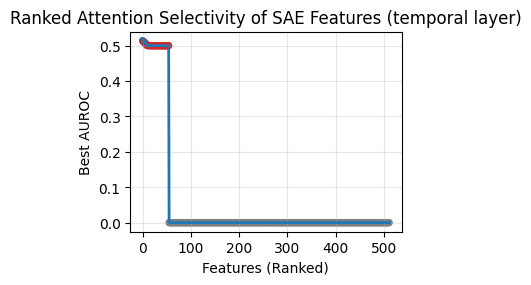

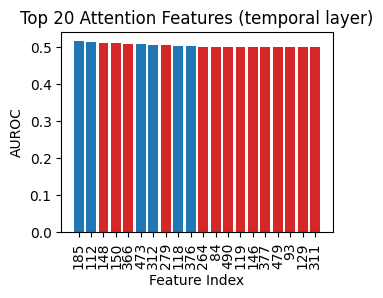

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 336
Best AUROC   : 0.5932
Detects      : Attended to left speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     336       0.593     Attended to left speaker
2     244       0.570     Attended to right speaker
3     340       0.567     Attended to right speaker
4     97        0.552     Attended to left speaker
5     27        0.549     Attended to right speaker
6     23        0.549     Attended to left speaker
7     395       0.546     Attended to right speaker
8     152       0.545     Attended to left speaker
9     240       0.538     Attended to left speaker
10    255       0.538     Attended to right speaker
11    482       0.538     Attended to right speaker
12    229       0.536     Attended to right speaker
13    399       0.535     Attended to left speaker
14    298       0.534     Attended to left speaker
15    457       0.533     Attended to right speaker
16    139       0.531     Attended to left speake

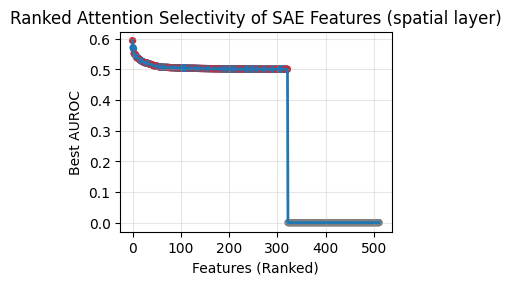

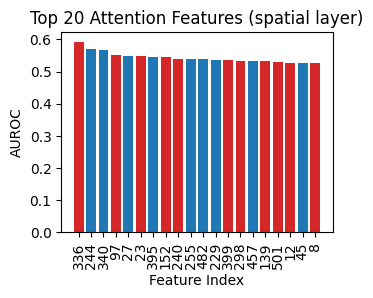

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 988
Best AUROC   : 0.5473
Detects      : Attended to left speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     988       0.547     Attended to left speaker
2     48        0.546     Attended to right speaker
3     166       0.541     Attended to right speaker
4     668       0.539     Attended to left speaker
5     473       0.538     Attended to right speaker
6     990       0.537     Attended to left speaker
7     494       0.537     Attended to right speaker
8     67        0.536     Attended to right speaker
9     243       0.534     Attended to left speaker
10    810       0.534     Attended to right speaker
11    288       0.534     Attended to left speaker
12    941       0.531     Attended to left speaker
13    957       0.531     Attended to left speaker
14    593       0.531     Attended to right speaker
15    952       0.531     Attended to right speaker
16    434       0.528     Attended to left speake

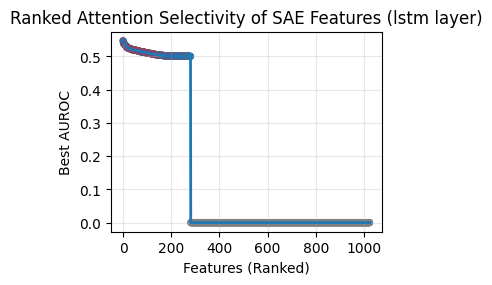

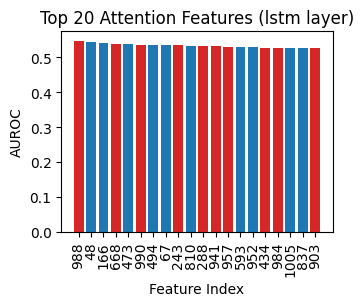

SAE on EEG activation from AAD model trained with seed 1


ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 394
Best AUROC   : 0.5235
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     394       0.524     Attended to right speaker
2     114       0.518     Attended to right speaker
3     505       0.514     Attended to right speaker
4     108       0.513     Attended to right speaker
5     152       0.512     Attended to right speaker
6     92        0.511     Attended to left speaker
7     359       0.511     Attended to left speaker
8     40        0.509     Attended to left speaker
9     67        0.506     Attended to right speaker
10    366       0.506     Attended to left speaker
11    97        0.505     Attended to right speaker
12    216       0.505     Attended to left speaker
13    164       0.503     Attended to left speaker
14    300       0.503     Attended to right speaker
15    320       0.502     Attended to le

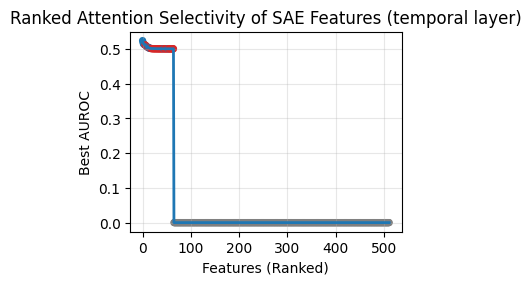

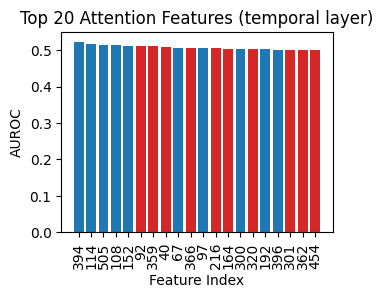

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 44
Best AUROC   : 0.5831
Detects      : Attended to left speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     44        0.583     Attended to left speaker
2     244       0.557     Attended to right speaker
3     126       0.554     Attended to right speaker
4     152       0.547     Attended to left speaker
5     247       0.545     Attended to left speaker
6     323       0.538     Attended to right speaker
7     491       0.538     Attended to left speaker
8     327       0.536     Attended to left speaker
9     159       0.536     Attended to right speaker
10    52        0.534     Attended to left speaker
11    194       0.533     Attended to left speaker
12    260       0.533     Attended to left speaker
13    449       0.530     Attended to left speaker
14    83        0.530     Attended to left speaker
15    36        0.529     Attended to right speaker
16    469       0.528     Attended to left speaker
17

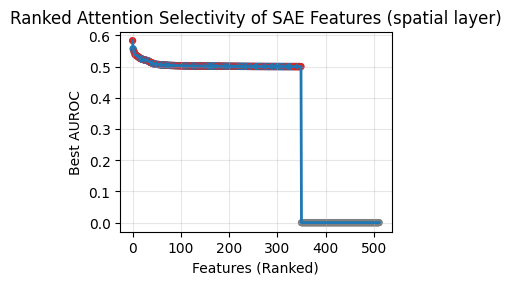

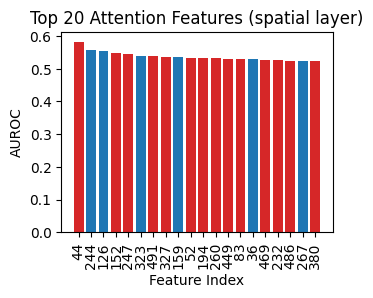

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 922
Best AUROC   : 0.5387
Detects      : Attended to left speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     922       0.539     Attended to left speaker
2     192       0.535     Attended to left speaker
3     148       0.535     Attended to left speaker
4     822       0.534     Attended to left speaker
5     988       0.533     Attended to right speaker
6     61        0.532     Attended to left speaker
7     477       0.532     Attended to right speaker
8     693       0.531     Attended to left speaker
9     851       0.531     Attended to left speaker
10    993       0.530     Attended to left speaker
11    599       0.530     Attended to right speaker
12    705       0.530     Attended to left speaker
13    445       0.530     Attended to left speaker
14    206       0.528     Attended to left speaker
15    805       0.528     Attended to left speaker
16    8         0.527     Attended to left speaker
17 

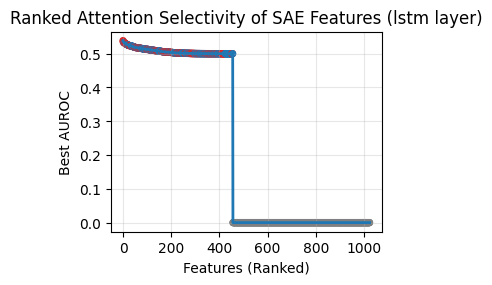

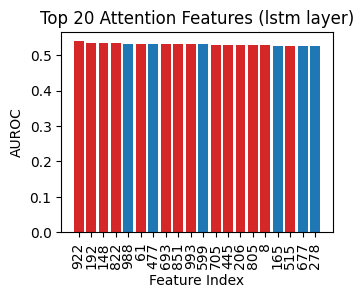

SAE on EEG activation from AAD model trained with seed 42


ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 82
Best AUROC   : 0.5179
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     82        0.518     Attended to right speaker
2     117       0.513     Attended to left speaker
3     247       0.512     Attended to right speaker
4     369       0.510     Attended to left speaker
5     43        0.509     Attended to right speaker
6     350       0.508     Attended to right speaker
7     494       0.508     Attended to left speaker
8     338       0.508     Attended to left speaker
9     173       0.507     Attended to right speaker
10    257       0.506     Attended to left speaker
11    114       0.504     Attended to left speaker
12    411       0.502     Attended to right speaker
13    24        0.502     Attended to left speaker
14    382       0.502     Attended to right speaker
15    153       0.502     Attended to lef

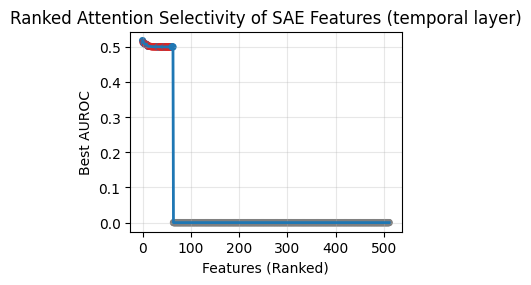

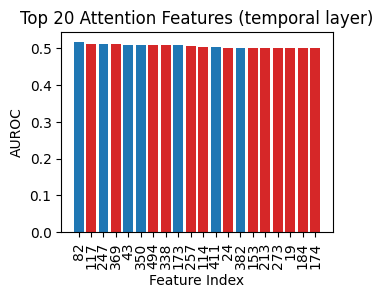

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 21
Best AUROC   : 0.5649
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     21        0.565     Attended to right speaker
2     419       0.562     Attended to left speaker
3     314       0.562     Attended to right speaker
4     408       0.561     Attended to right speaker
5     97        0.553     Attended to right speaker
6     50        0.551     Attended to right speaker
7     450       0.545     Attended to left speaker
8     275       0.545     Attended to left speaker
9     326       0.545     Attended to left speaker
10    372       0.541     Attended to right speaker
11    135       0.539     Attended to right speaker
12    171       0.538     Attended to left speaker
13    376       0.535     Attended to right speaker
14    353       0.533     Attended to right speaker
15    455       0.533     Attended to right speaker
16    210       0.527     Attended to left spea

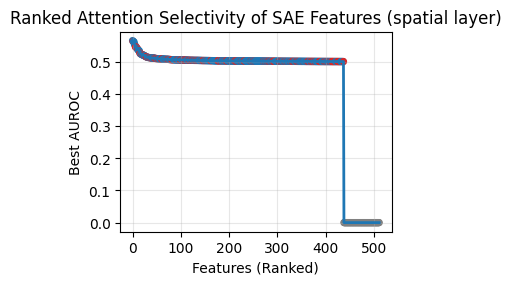

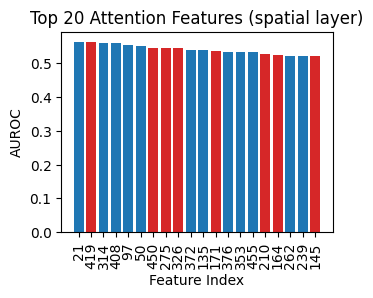

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 789
Best AUROC   : 0.5416
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     789       0.542     Attended to right speaker
2     379       0.539     Attended to left speaker
3     970       0.537     Attended to left speaker
4     634       0.534     Attended to right speaker
5     356       0.533     Attended to right speaker
6     644       0.532     Attended to right speaker
7     788       0.530     Attended to right speaker
8     448       0.530     Attended to left speaker
9     772       0.529     Attended to right speaker
10    280       0.528     Attended to right speaker
11    311       0.528     Attended to right speaker
12    145       0.527     Attended to right speaker
13    313       0.526     Attended to left speaker
14    843       0.526     Attended to right speaker
15    862       0.526     Attended to left speaker
16    304       0.525     Attended to left spe

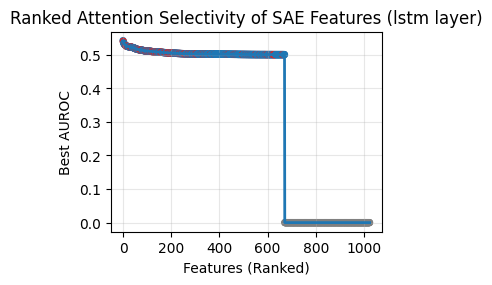

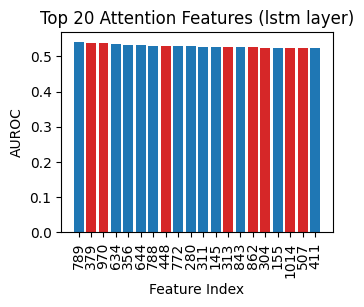

SAE on EEG activation from AAD model trained with seed 100


ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 406
Best AUROC   : 0.5243
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     406       0.524     Attended to right speaker
2     69        0.522     Attended to left speaker
3     228       0.520     Attended to left speaker
4     194       0.518     Attended to right speaker
5     443       0.514     Attended to left speaker
6     5         0.512     Attended to right speaker
7     46        0.512     Attended to right speaker
8     17        0.510     Attended to left speaker
9     7         0.510     Attended to left speaker
10    141       0.507     Attended to left speaker
11    270       0.507     Attended to left speaker
12    494       0.506     Attended to right speaker
13    48        0.505     Attended to right speaker
14    450       0.505     Attended to right speaker
15    90        0.505     Attended to r

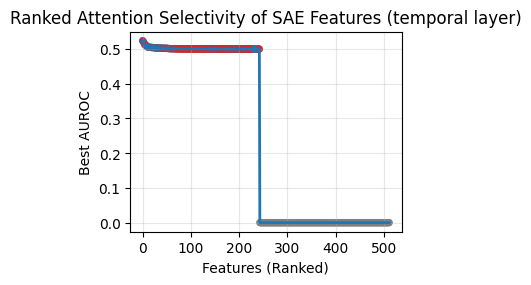

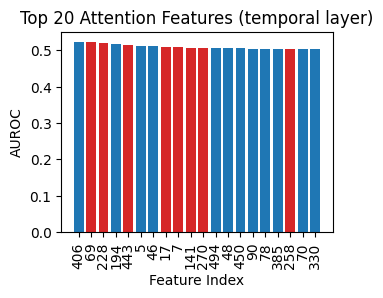

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 394
Best AUROC   : 0.5511
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     394       0.551     Attended to right speaker
2     276       0.550     Attended to right speaker
3     28        0.548     Attended to left speaker
4     327       0.547     Attended to left speaker
5     166       0.545     Attended to left speaker
6     160       0.545     Attended to left speaker
7     406       0.544     Attended to left speaker
8     130       0.541     Attended to left speaker
9     331       0.540     Attended to left speaker
10    418       0.539     Attended to left speaker
11    11        0.539     Attended to left speaker
12    333       0.539     Attended to left speaker
13    422       0.538     Attended to right speaker
14    273       0.538     Attended to right speaker
15    478       0.538     Attended to right speaker
16    158       0.535     Attended to right speaker

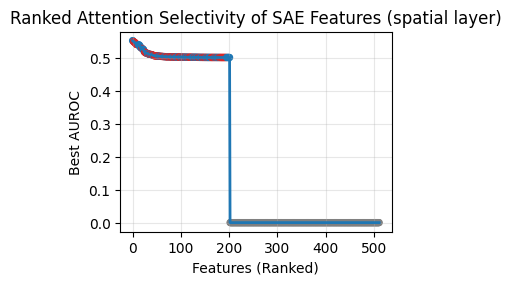

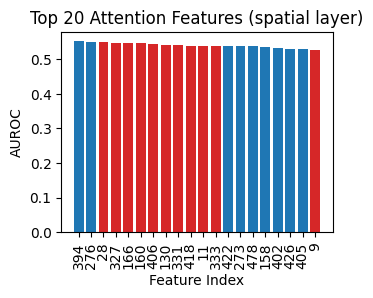

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 178
Best AUROC   : 0.5484
Detects      : Attended to left speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     178       0.548     Attended to left speaker
2     687       0.546     Attended to left speaker
3     226       0.546     Attended to left speaker
4     445       0.544     Attended to left speaker
5     9         0.542     Attended to left speaker
6     956       0.542     Attended to left speaker
7     1012      0.541     Attended to left speaker
8     368       0.540     Attended to right speaker
9     548       0.540     Attended to left speaker
10    10        0.539     Attended to right speaker
11    194       0.539     Attended to left speaker
12    934       0.539     Attended to left speaker
13    36        0.539     Attended to left speaker
14    675       0.538     Attended to left speaker
15    154       0.535     Attended to left speaker
16    809       0.534     Attended to left speaker
17  

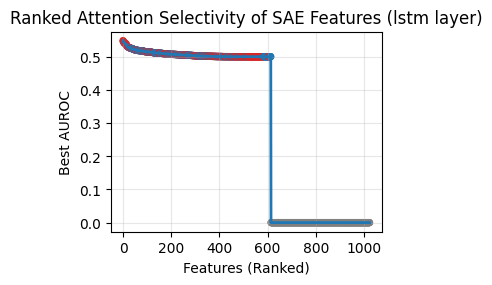

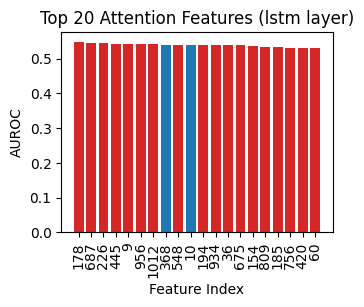

In [12]:
print("SAE on EEG activation from AAD model trained with seed 0")
print("\n")
result_dict_temporal = attention_specificity(z_temporal_0, labels, "temporal", "seed_0", save_path = "/kaggle/working/")
result_dict_spatial = attention_specificity(z_spatial_0, labels, "spatial", "seed_0", save_path = "/kaggle/working/")
result_dict_lstm = attention_specificity(z_lstm_0, labels, "lstm", "seed_0", save_path = "/kaggle/working/")

print("SAE on EEG activation from AAD model trained with seed 1")
print("\n")
result_dict_temporal = attention_specificity(z_temporal_1, labels, "temporal", "seed_1", save_path = "/kaggle/working/")
result_dict_spatial = attention_specificity(z_spatial_1, labels, "spatial", "seed_1", save_path = "/kaggle/working/")
result_dict_lstm = attention_specificity(z_lstm_1, labels, "lstm", "seed_1", save_path = "/kaggle/working/")


print("SAE on EEG activation from AAD model trained with seed 42")
print("\n")
result_dict_temporal = attention_specificity(z_temporal_42, labels, "temporal", "seed_42", save_path = "/kaggle/working/")
result_dict_spatial = attention_specificity(z_spatial_42, labels, "spatial", "seed_42", save_path = "/kaggle/working/")
result_dict_lstm = attention_specificity(z_lstm_42, labels, "lstm", "seed_42", save_path = "/kaggle/working/")


print("SAE on EEG activation from AAD model trained with seed 100")
print("\n")
result_dict_temporal = attention_specificity(z_temporal_100, labels, "temporal", "seed_100", save_path = "/kaggle/working/")
result_dict_spatial = attention_specificity(z_spatial_100, labels, "spatial", "seed_100", save_path = "/kaggle/working/")
result_dict_lstm = attention_specificity(z_lstm_100, labels, "lstm", "seed_100", save_path = "/kaggle/working/")

# **Max Stat permutation test**

In [13]:
r_temporal = max_stat_permutation_test(z_temporal_0, labels, n_perms=2000, seed=0)
r_spatial  = max_stat_permutation_test(z_spatial_0, labels, n_perms=2000, seed=0)
r_lstm     = max_stat_permutation_test(z_lstm_0, labels, n_perms=2000, seed=0)
print(r_temporal)
print(r_spatial)
print(r_lstm)


r_temporal = max_stat_permutation_test(z_temporal_1, labels, n_perms=2000, seed=0)
r_spatial  = max_stat_permutation_test(z_spatial_1, labels, n_perms=2000, seed=0)
r_lstm     = max_stat_permutation_test(z_lstm_1, labels, n_perms=2000, seed=0)
print(r_temporal)
print(r_spatial)
print(r_lstm)


r_temporal = max_stat_permutation_test(z_temporal_42, labels, n_perms=2000, seed=0)
r_spatial  = max_stat_permutation_test(z_spatial_42, labels, n_perms=2000, seed=0)
r_lstm     = max_stat_permutation_test(z_lstm_42, labels, n_perms=2000, seed=0)
print(r_temporal)
print(r_spatial)
print(r_lstm)




r_temporal = max_stat_permutation_test(z_temporal_100, labels, n_perms=2000, seed=0)
r_spatial  = max_stat_permutation_test(z_spatial_100, labels, n_perms=2000, seed=0)
r_lstm     = max_stat_permutation_test(z_lstm_100, labels, n_perms=2000, seed=0)
print(r_temporal)
print(r_spatial)
print(r_lstm)

{'best_feature_idx': 185, 'best_auc': 0.5142, 'null_95': 0.508, 'null_99': 0.5099, 'pvalue': 0.0005, 'n_dead_features': 457, 'n_perms': 2000, 'seed': 0}
{'best_feature_idx': 336, 'best_auc': 0.5932, 'null_95': 0.5103, 'null_99': 0.5121, 'pvalue': 0.0005, 'n_dead_features': 190, 'n_perms': 2000, 'seed': 0}
{'best_feature_idx': 988, 'best_auc': 0.5473, 'null_95': 0.5075, 'null_99': 0.5084, 'pvalue': 0.0005, 'n_dead_features': 743, 'n_perms': 2000, 'seed': 0}
{'best_feature_idx': 394, 'best_auc': 0.5235, 'null_95': 0.5085, 'null_99': 0.5106, 'pvalue': 0.0005, 'n_dead_features': 447, 'n_perms': 2000, 'seed': 0}
{'best_feature_idx': 44, 'best_auc': 0.5831, 'null_95': 0.5102, 'null_99': 0.5119, 'pvalue': 0.0005, 'n_dead_features': 162, 'n_perms': 2000, 'seed': 0}
{'best_feature_idx': 922, 'best_auc': 0.5387, 'null_95': 0.5084, 'null_99': 0.5097, 'pvalue': 0.0005, 'n_dead_features': 568, 'n_perms': 2000, 'seed': 0}
{'best_feature_idx': 82, 'best_auc': 0.5179, 'null_95': 0.5087, 'null_99': 0.5

# **Subject Specificity analysis**

SAE on EEG activation from AAD model trained with seed 0


SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 376 | AUROC 0.732
Subject  1 | Best Feature 118 | AUROC 0.823
Subject  2 | Best Feature 118 | AUROC 0.619
Subject  5 | Best Feature 112 | AUROC 0.646


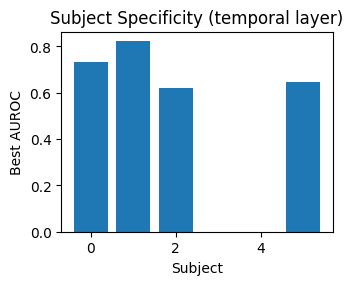

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 298 | AUROC 0.690
Subject  1 | Best Feature 263 | AUROC 0.742
Subject  2 | Best Feature 263 | AUROC 0.612
Subject  5 | Best Feature 372 | AUROC 0.608


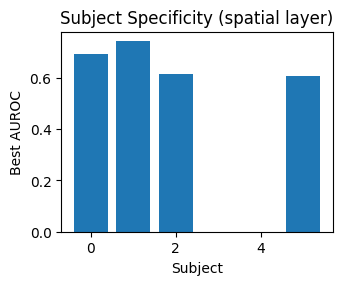

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 516 | AUROC 0.641
Subject  1 | Best Feature 770 | AUROC 0.640
Subject  2 | Best Feature 845 | AUROC 0.610
Subject  5 | Best Feature 593 | AUROC 0.595


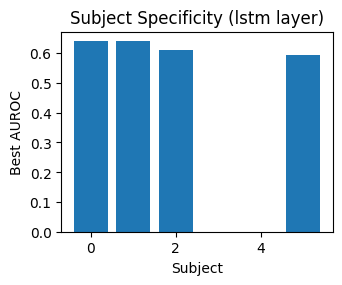

SAE on EEG activation from AAD model trained with seed 1


SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 192 | AUROC 0.744
Subject  1 | Best Feature 114 | AUROC 0.993
Subject  2 | Best Feature 114 | AUROC 0.686
Subject  5 | Best Feature  67 | AUROC 0.680


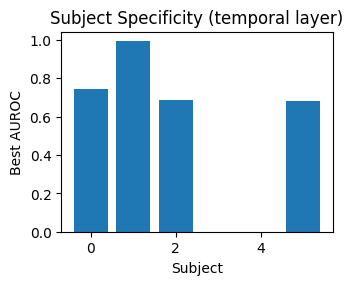

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 376 | AUROC 0.672
Subject  1 | Best Feature 153 | AUROC 0.661
Subject  2 | Best Feature 308 | AUROC 0.647
Subject  5 | Best Feature  54 | AUROC 0.695


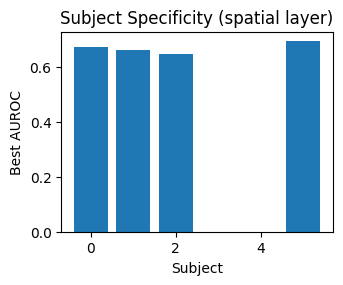

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 104 | AUROC 0.615
Subject  1 | Best Feature 764 | AUROC 0.613
Subject  2 | Best Feature 319 | AUROC 0.590
Subject  5 | Best Feature 123 | AUROC 0.647


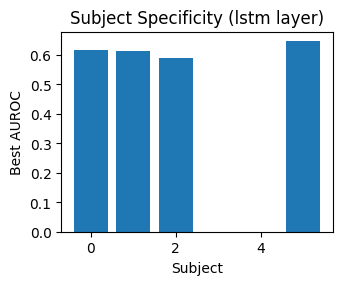

SAE on EEG activation from AAD model trained with seed 42


SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 411 | AUROC 0.729
Subject  1 | Best Feature 213 | AUROC 0.998
Subject  2 | Best Feature 213 | AUROC 0.691
Subject  5 | Best Feature 213 | AUROC 0.665


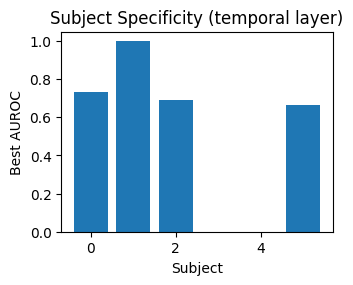

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 273 | AUROC 0.608
Subject  1 | Best Feature  87 | AUROC 0.705
Subject  2 | Best Feature 253 | AUROC 0.661
Subject  5 | Best Feature 353 | AUROC 0.639


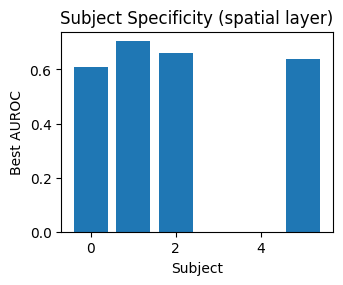

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 111 | AUROC 0.624
Subject  1 | Best Feature 264 | AUROC 0.581
Subject  2 | Best Feature 772 | AUROC 0.581
Subject  5 | Best Feature 306 | AUROC 0.574


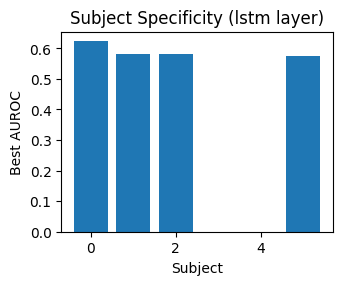

SAE on EEG activation from AAD model trained with seed 100


SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 222 | AUROC 0.744
Subject  1 | Best Feature  48 | AUROC 0.999
Subject  2 | Best Feature 443 | AUROC 0.715
Subject  5 | Best Feature  48 | AUROC 0.698


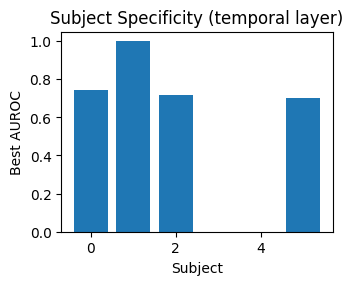

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 468 | AUROC 0.668
Subject  1 | Best Feature 166 | AUROC 0.635
Subject  2 | Best Feature 413 | AUROC 0.674
Subject  5 | Best Feature 426 | AUROC 0.723


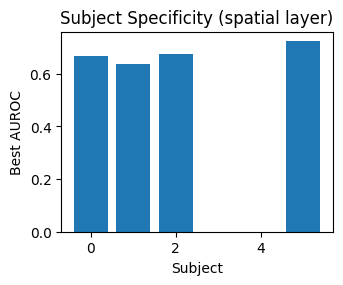

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 319 | AUROC 0.624
Subject  1 | Best Feature 863 | AUROC 0.575
Subject  2 | Best Feature 768 | AUROC 0.570
Subject  5 | Best Feature 988 | AUROC 0.574


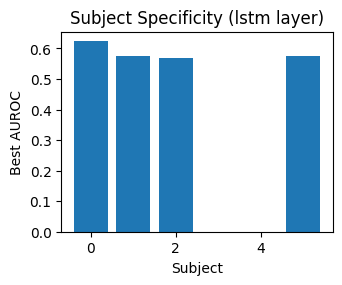

In [14]:
print("SAE on EEG activation from AAD model trained with seed 0")
print("\n")
result_temporal = subject_specificity(z_temporal_0, subjects, "temporal", "seed_0", save_path = "/kaggle/working/")
result_spatial = subject_specificity(z_spatial_0, subjects, "spatial", "seed_0", save_path = "/kaggle/working/")
result_lstm = subject_specificity(z_lstm_0, subjects, "lstm", "seed_0", save_path = "/kaggle/working/")


print("SAE on EEG activation from AAD model trained with seed 1")
print("\n")
result_temporal = subject_specificity(z_temporal_1, subjects, "temporal", "seed_1", save_path = "/kaggle/working/")
result_spatial = subject_specificity(z_spatial_1, subjects, "spatial", "seed_1", save_path = "/kaggle/working/")
result_lstm = subject_specificity(z_lstm_1, subjects, "lstm", "seed_1", save_path = "/kaggle/working/")


print("SAE on EEG activation from AAD model trained with seed 42")
print("\n")
result_temporal = subject_specificity(z_temporal_42, subjects, "temporal", "seed_42", save_path = "/kaggle/working/")
result_spatial = subject_specificity(z_spatial_42, subjects, "spatial", "seed_42", save_path = "/kaggle/working/")
result_lstm = subject_specificity(z_lstm_42, subjects, "lstm", "seed_42", save_path = "/kaggle/working/")


print("SAE on EEG activation from AAD model trained with seed 100")
print("\n")
result_temporal = subject_specificity(z_temporal_100, subjects, "temporal", "seed_100", save_path = "/kaggle/working/")
result_spatial = subject_specificity(z_spatial_100, subjects, "spatial", "seed_100", save_path = "/kaggle/working/")
result_lstm = subject_specificity(z_lstm_100, subjects, "lstm", "seed_100", save_path = "/kaggle/working/")

# **Task vs Subject Specificity analysis**

SAE on EEG activation from AAD model trained with seed 0


TASK vs SUBJECT FEATURE ANALYSIS


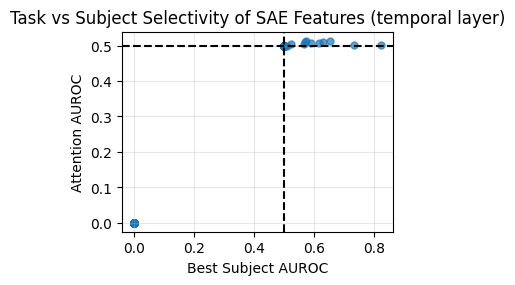

Task-dominant Features    : 3
Subject-dominant Features : 52
Equal                     : 457
Top Task-selective Features
Feature   Task      Subject
185       0.514     0.573
112       0.512     0.654
148       0.511     0.630
150       0.510     0.570
366       0.509     0.616
473       0.508     0.590
312       0.506     0.523
279       0.504     0.566
118       0.501     0.823
376       0.501     0.732
Top Subject-selective Features
Feature   Subject   Task
118       0.823     0.501
376       0.732     0.501
112       0.654     0.512
148       0.630     0.511
366       0.616     0.509
473       0.590     0.508
185       0.573     0.514
150       0.570     0.510
279       0.566     0.504
312       0.523     0.506
TASK vs SUBJECT FEATURE ANALYSIS


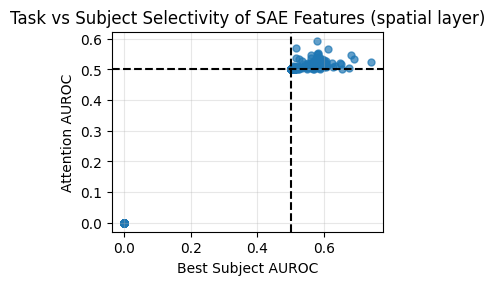

Task-dominant Features    : 10
Subject-dominant Features : 312
Equal                     : 191
Top Task-selective Features
Feature   Task      Subject
336       0.593     0.578
244       0.570     0.518
340       0.567     0.612
97        0.552     0.583
27        0.549     0.580
23        0.549     0.584
395       0.546     0.682
152       0.545     0.562
240       0.538     0.584
255       0.538     0.517
Top Subject-selective Features
Feature   Subject   Task
263       0.742     0.524
298       0.690     0.534
395       0.682     0.546
43        0.675     0.505
215       0.654     0.501
1         0.653     0.516
270       0.650     0.521
247       0.635     0.510
190       0.627     0.507
273       0.624     0.519
TASK vs SUBJECT FEATURE ANALYSIS


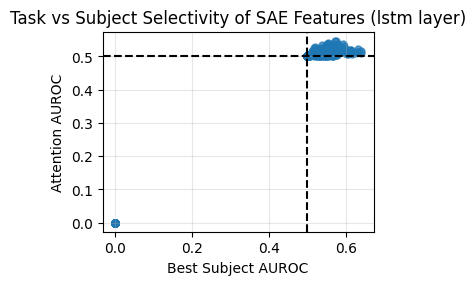

Task-dominant Features    : 7
Subject-dominant Features : 274
Equal                     : 744
Top Task-selective Features
Feature   Task      Subject
988       0.547     0.574
48        0.546     0.572
166       0.541     0.554
668       0.539     0.579
473       0.538     0.592
990       0.537     0.564
494       0.537     0.553
67        0.536     0.554
243       0.534     0.539
810       0.534     0.548
Top Subject-selective Features
Feature   Subject   Task
516       0.641     0.516
770       0.640     0.509
763       0.632     0.513
77        0.631     0.521
120       0.629     0.513
1007      0.624     0.509
506       0.617     0.508
158       0.614     0.517
820       0.613     0.520
571       0.611     0.511
SAE on EEG activation from AAD model trained with seed 1


TASK vs SUBJECT FEATURE ANALYSIS


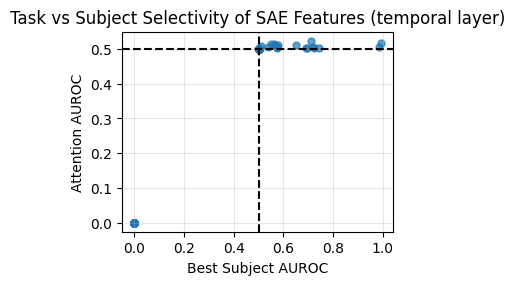

Task-dominant Features    : 5
Subject-dominant Features : 60
Equal                     : 448
Top Task-selective Features
Feature   Task      Subject
394       0.524     0.711
114       0.518     0.993
505       0.514     0.562
108       0.513     0.550
152       0.512     0.649
92        0.511     0.566
359       0.511     0.580
40        0.509     0.508
67        0.506     0.984
366       0.506     0.573
Top Subject-selective Features
Feature   Subject   Task
114       0.993     0.518
67        0.984     0.506
192       0.744     0.502
300       0.724     0.503
97        0.718     0.505
394       0.711     0.524
320       0.697     0.502
396       0.691     0.501
152       0.649     0.512
359       0.580     0.511
TASK vs SUBJECT FEATURE ANALYSIS


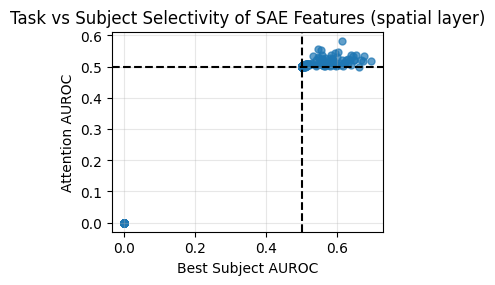

Task-dominant Features    : 9
Subject-dominant Features : 341
Equal                     : 162
Top Task-selective Features
Feature   Task      Subject
44        0.583     0.612
244       0.557     0.546
126       0.554     0.554
152       0.547     0.603
247       0.545     0.593
323       0.538     0.557
491       0.538     0.639
327       0.536     0.652
159       0.536     0.583
52        0.534     0.675
Top Subject-selective Features
Feature   Subject   Task
54        0.695     0.517
52        0.675     0.534
376       0.672     0.517
334       0.665     0.521
153       0.661     0.500
327       0.652     0.536
180       0.648     0.521
308       0.647     0.521
194       0.645     0.533
491       0.639     0.538
TASK vs SUBJECT FEATURE ANALYSIS


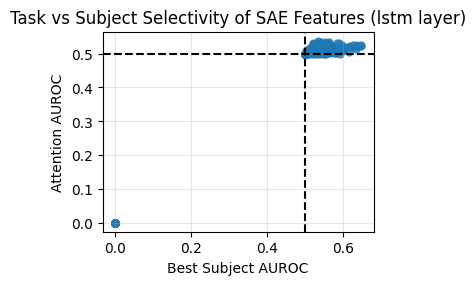

Task-dominant Features    : 15
Subject-dominant Features : 441
Equal                     : 569
Top Task-selective Features
Feature   Task      Subject
922       0.539     0.532
192       0.535     0.562
148       0.535     0.551
822       0.534     0.542
988       0.533     0.559
61        0.532     0.589
477       0.532     0.584
693       0.531     0.557
851       0.531     0.534
993       0.530     0.521
Top Subject-selective Features
Feature   Subject   Task
123       0.647     0.522
887       0.645     0.525
438       0.640     0.523
51        0.639     0.522
17        0.633     0.525
377       0.633     0.514
806       0.631     0.521
278       0.626     0.526
954       0.618     0.521
406       0.616     0.524
SAE on EEG activation from AAD model trained with seed 42


TASK vs SUBJECT FEATURE ANALYSIS


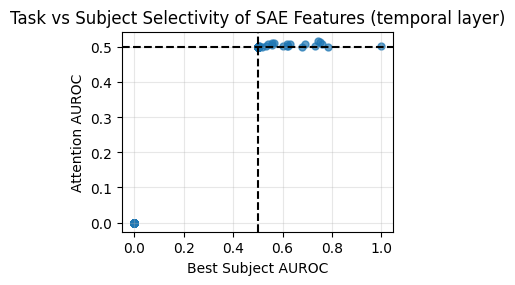

Task-dominant Features    : 2
Subject-dominant Features : 62
Equal                     : 449
Top Task-selective Features
Feature   Task      Subject
82        0.518     0.741
117       0.513     0.751
247       0.512     0.557
369       0.510     0.566
43        0.509     0.619
350       0.508     0.542
494       0.508     0.629
338       0.508     0.760
173       0.507     0.691
257       0.506     0.558
Top Subject-selective Features
Feature   Subject   Task
213       0.998     0.502
174       0.784     0.501
338       0.760     0.508
117       0.751     0.513
82        0.741     0.518
411       0.729     0.502
173       0.691     0.507
49        0.678     0.500
494       0.629     0.508
273       0.623     0.501
TASK vs SUBJECT FEATURE ANALYSIS


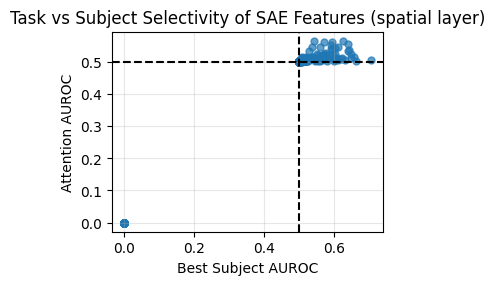

Task-dominant Features    : 27
Subject-dominant Features : 411
Equal                     : 74
Top Task-selective Features
Feature   Task      Subject
21        0.565     0.541
419       0.562     0.625
314       0.562     0.593
408       0.561     0.571
97        0.553     0.638
50        0.551     0.591
450       0.545     0.612
275       0.545     0.536
326       0.545     0.559
372       0.541     0.601
Top Subject-selective Features
Feature   Subject   Task
87        0.705     0.504
253       0.661     0.500
273       0.657     0.513
409       0.649     0.512
164       0.646     0.524
376       0.643     0.535
353       0.639     0.533
97        0.638     0.553
349       0.630     0.506
419       0.625     0.562
TASK vs SUBJECT FEATURE ANALYSIS


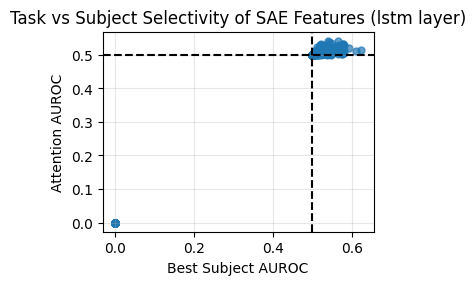

Task-dominant Features    : 31
Subject-dominant Features : 640
Equal                     : 354
Top Task-selective Features
Feature   Task      Subject
789       0.542     0.564
379       0.539     0.539
970       0.537     0.543
634       0.534     0.548
356       0.533     0.577
644       0.532     0.578
788       0.530     0.523
448       0.530     0.529
772       0.529     0.581
280       0.528     0.520
Top Subject-selective Features
Feature   Subject   Task
111       0.624     0.515
286       0.609     0.511
264       0.593     0.521
772       0.581     0.529
477       0.580     0.505
941       0.579     0.513
155       0.578     0.525
644       0.578     0.532
774       0.578     0.508
356       0.577     0.533
SAE on EEG activation from AAD model trained with seed 100


TASK vs SUBJECT FEATURE ANALYSIS


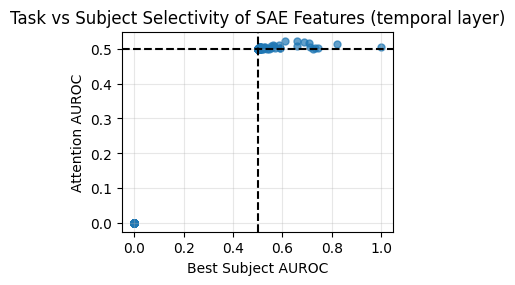

Task-dominant Features    : 10
Subject-dominant Features : 233
Equal                     : 269
Top Task-selective Features
Feature   Task      Subject
406       0.524     0.609
69        0.522     0.660
228       0.520     0.689
194       0.518     0.707
443       0.514     0.823
5         0.512     0.585
46        0.512     0.563
17        0.510     0.567
7         0.510     0.554
141       0.507     0.657
Top Subject-selective Features
Feature   Subject   Task
48        0.999     0.505
443       0.823     0.514
222       0.744     0.502
1         0.731     0.502
354       0.722     0.500
270       0.711     0.507
194       0.707     0.518
228       0.689     0.520
69        0.660     0.522
141       0.657     0.507
TASK vs SUBJECT FEATURE ANALYSIS


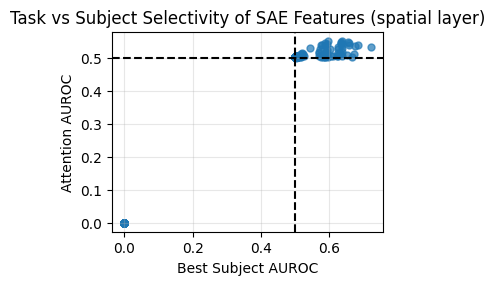

Task-dominant Features    : 2
Subject-dominant Features : 200
Equal                     : 310
Top Task-selective Features
Feature   Task      Subject
394       0.551     0.638
276       0.550     0.597
28        0.548     0.655
327       0.547     0.635
166       0.545     0.635
160       0.545     0.660
406       0.544     0.588
130       0.541     0.636
331       0.540     0.595
418       0.539     0.639
Top Subject-selective Features
Feature   Subject   Task
426       0.723     0.530
478       0.684     0.538
158       0.675     0.535
413       0.674     0.510
468       0.668     0.501
422       0.660     0.538
160       0.660     0.545
28        0.655     0.548
393       0.654     0.509
138       0.639     0.503
TASK vs SUBJECT FEATURE ANALYSIS


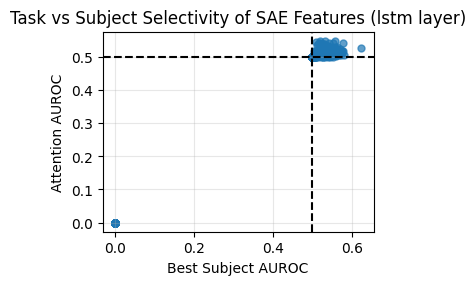

Task-dominant Features    : 44
Subject-dominant Features : 570
Equal                     : 410
Top Task-selective Features
Feature   Task      Subject
178       0.548     0.557
687       0.546     0.520
226       0.546     0.532
445       0.544     0.509
9         0.542     0.518
956       0.542     0.543
1012      0.541     0.552
368       0.540     0.517
548       0.540     0.577
10        0.539     0.530
Top Subject-selective Features
Feature   Subject   Task
319       0.624     0.525
570       0.580     0.506
789       0.579     0.518
548       0.577     0.540
863       0.575     0.518
361       0.574     0.511
988       0.574     0.516
205       0.573     0.504
598       0.573     0.510
768       0.570     0.510


In [15]:
print("SAE on EEG activation from AAD model trained with seed 0")
print("\n")
score_temporal = task_vs_subject_analysis(z_temporal_0, labels, subjects, "temporal", "seed_0", save_path = "/kaggle/working/")
score_spatial = task_vs_subject_analysis(z_spatial_0, labels, subjects, "spatial", "seed_0", save_path = "/kaggle/working/")
score_lstm = task_vs_subject_analysis(z_lstm_0, labels, subjects, "lstm", "seed_0", save_path = "/kaggle/working/")


print("SAE on EEG activation from AAD model trained with seed 1")
print("\n")
score_temporal = task_vs_subject_analysis(z_temporal_1, labels, subjects, "temporal", "seed_1", save_path = "/kaggle/working/")
score_spatial = task_vs_subject_analysis(z_spatial_1, labels, subjects, "spatial", "seed_1", save_path = "/kaggle/working/")
score_lstm = task_vs_subject_analysis(z_lstm_1, labels, subjects, "lstm", "seed_1", save_path = "/kaggle/working/")


print("SAE on EEG activation from AAD model trained with seed 42")
print("\n")
score_temporal = task_vs_subject_analysis(z_temporal_42, labels, subjects, "temporal", "seed_42", save_path = "/kaggle/working/")
score_spatial = task_vs_subject_analysis(z_spatial_42, labels, subjects, "spatial", "seed_42", save_path = "/kaggle/working/")
score_lstm = task_vs_subject_analysis(z_lstm_42, labels, subjects, "lstm", "seed_42", save_path = "/kaggle/working/")


print("SAE on EEG activation from AAD model trained with seed 100")
print("\n")
score_temporal = task_vs_subject_analysis(z_temporal_100, labels, subjects, "temporal", "seed_100", save_path = "/kaggle/working/")
score_spatial = task_vs_subject_analysis(z_spatial_100, labels, subjects, "spatial", "seed_100", save_path = "/kaggle/working/")
score_lstm = task_vs_subject_analysis(z_lstm_100, labels, subjects, "lstm", "seed_100", save_path = "/kaggle/working/")